In [1]:
!pip install --quiet keras-tcn

In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import glob
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Olası sürüm uyarılarını gizle
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV




In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"{len(gpus)} adet GPU bulundu ve memory growth ayarlandı.")
    except RuntimeError as e:
        print(e)
else:
    print("UYARI: GPU bulunamadı! DL model tahminleri CPU üzerinde yavaş olabilir.")

1 adet GPU bulundu ve memory growth ayarlandı.


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("\nDrive bağlandı.")

Mounted at /content/drive

Drive bağlandı.


In [5]:
# --- Sabit Yollar ---
DRIVE_BASE_PATH = '/content/drive/MyDrive/Colab_ECG_Data/'
# Ham Sinyaller (DL için)
ORIG_SIGNALS_PATH = os.path.join(DRIVE_BASE_PATH, 'processed', 'signals')
# Öznitelikler (ML için)
PROCESSED_DATA_PATH = os.path.join(DRIVE_BASE_PATH, 'processed')
# GAN ile eğitilmiş modellerin yolları (Parametre okumak için)
ML_GAN_MODELS_PATH = os.path.join(DRIVE_BASE_PATH, 'models', 'gan_balanced')
DL_GAN_MODELS_PATH = os.path.join(DRIVE_BASE_PATH, 'models', 'dl_gan_balanced')
# Ensemble sonuçlarını kaydedeceğimiz yer
ENSEMBLE_PATH = os.path.join(DRIVE_BASE_PATH, 'models', 'ensemble')
os.makedirs(ENSEMBLE_PATH, exist_ok=True)

print("\nTüm yollar ve sabitler ayarlandı.")

print("Doğrulama (Validation), Test ve EĞİTİM (TRAIN) setleri yükleniyor...")

try:
    # --- ML Verileri (Öznitelikler) ---
    print("ML (Öznitelik) verileri yükleniyor...")

    # --- GERÇEK DÜZELTME BURADA (Dosya adlarından '_feat_' kaldırıldı) ---
    X_train_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_train_balanced.npy'))
    y_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_train_balanced.npy'))
    # --- DÜZELTME BİTTİ ---

    X_val_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_val_feat.npy'))
    y_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'))

    X_test_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test_feat.npy'))
    y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))
    print(f"ML Verileri Yüklendi. Eğitim seti boyutu: {X_train_feat.shape}")

    # --- DL Verileri (Ham Sinyaller) ---
    print("DL (Ham Sinyal) verileri yükleniyor... (Sadece Val ve Test)")
    X_val_sig = np.load(os.path.join(ORIG_SIGNALS_PATH, 'X_val_sig.npy'))
    X_test_sig = np.load(os.path.join(ORIG_SIGNALS_PATH, 'X_test_sig.npy'))
    print("DL Verileri Yüklendi.")

    # --- NaN Doldurma (Imputation) ---
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train_feat) # EĞİTİM'e fit et
    X_val_imputed = imputer.transform(X_val_feat)       # VAL'e uygula
    X_test_imputed = imputer.transform(X_test_feat)     # TEST'e uygula
    print("ML verileri için NaN doldurma (Imputation) yapıldı.")

    # --- ML Ölçekleme (Standardizasyon) ---
    scaler_ml_path = os.path.join(ML_GAN_MODELS_PATH, 'scaler_balanced.pkl')
    scaler_ml = joblib.load(scaler_ml_path)
    print(f"ML Scaler ({scaler_ml_path}) yüklendi.")

    X_train_scaled = scaler_ml.transform(X_train_imputed)
    X_val_scaled = scaler_ml.transform(X_val_imputed)
    X_test_scaled = scaler_ml.transform(X_test_imputed)
    print("ML (Öznitelik) verileri standardize edildi (Train, Val, Test).")

    # --- DL Ölçekleme (Standardizasyon) ---
    scaler_dl_path = os.path.join(DL_GAN_MODELS_PATH, 'dl_scaler_gan.pkl')
    scaler_dl = joblib.load(scaler_dl_path)
    print(f"DL Scaler ({scaler_dl_path}) yüklendi.")

    N_LEADS = X_val_sig.shape[2]
    def scale_data(data, scaler_obj):
        data_reshaped = data.reshape(-1, N_LEADS)
        data_scaled = scaler_obj.transform(data_reshaped)
        return data_scaled.reshape(data.shape)

    X_val_scaled_dl = scale_data(X_val_sig, scaler_dl)
    X_test_scaled_dl = scale_data(X_test_sig, scaler_dl)
    print("DL (Sinyal) verileri standardize edildi (Val, Test).")

    # --- Etiketleri Kategorik Hale Getir (Keras ve ROC AUC için) ---
    N_CLASSES = 5
    y_val_cat = to_categorical(y_val, num_classes=N_CLASSES)
    y_test_cat = to_categorical(y_test, num_classes=N_CLASSES)
    print("Etiketler 'categorical' formata dönüştürüldü.")

except FileNotFoundError as e:
    print(f"HATA: Veri yükleme sırasında dosya bulunamadı: {e}")
    print("Lütfen dosya yollarının ve adlarının (örn: 'X_train_balanced.npy') doğruluğunu kontrol edin.")
    raise
except Exception as e:
    print(f"HATA: Veri yükleme veya ölçekleme sırasında hata oluştu: {e}")
    raise


Tüm yollar ve sabitler ayarlandı.
Doğrulama (Validation), Test ve EĞİTİM (TRAIN) setleri yükleniyor...
ML (Öznitelik) verileri yükleniyor...
ML Verileri Yüklendi. Eğitim seti boyutu: (173949, 147)
DL (Ham Sinyal) verileri yükleniyor... (Sadece Val ve Test)
DL Verileri Yüklendi.
ML verileri için NaN doldurma (Imputation) yapıldı.
ML Scaler (/content/drive/MyDrive/Colab_ECG_Data/models/gan_balanced/scaler_balanced.pkl) yüklendi.
ML (Öznitelik) verileri standardize edildi (Train, Val, Test).
DL Scaler (/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/dl_scaler_gan.pkl) yüklendi.
DL (Sinyal) verileri standardize edildi (Val, Test).
Etiketler 'categorical' formata dönüştürüldü.


In [6]:
# --- HÜCRE 3: DL Modellerini YENİDEN OLUŞTURMA ve AĞIRLIKLARI YÜKLEME ---

import re
import glob
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, BatchNormalization, SpatialDropout1D,
    Bidirectional, AdditiveAttention, GlobalAveragePooling1D,
    Conv1D, ReLU, Add
)
from tensorflow.keras.models import Model
# from tcn import TCN # Bu import artık gereksiz, TCN'i manuel tanımladın

print("Eğitilmiş (GAN'lı) DL Modelleri yükleniyor...")
print("DÜZELTME: 'load_model' yerine 'model.load_weights' kullanılacak.")
print("Model mimarileri (iskeletler) koddan oluşturuluyor...")

# --- 1. MODEL MİMARİLERİ (İSKELETLER) ---
# Senin sağladığın DL eğitim kodları (hiçbir değişiklik yapılmadı)

def build_lstm_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)
    x = SpatialDropout1D(0.1)(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = BatchNormalization()(x)
    attn_output = AdditiveAttention(name='attention_layer')([x, x])
    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    # Not: compile() ayarları ağırlık yüklerken (inference) gerekli değildir,
    # ama tutarlılık için ekliyoruz.
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def tcn_block(inputs, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)
    if inputs.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(inputs)
    else:
        shortcut = inputs
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_tcn_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)
    x = tcn_block(inputs, 64, 3, dilation_rate=1)
    x = tcn_block(x, 64, 3, dilation_rate=2)
    x = tcn_block(x, 128, 3, dilation_rate=4)
    x = tcn_block(x, 128, 3, dilation_rate=8)
    attn_output = AdditiveAttention(name='attention_layer')([x, x])
    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def resnet_identity_block(inputs, filters, kernel_size):
    shortcut = inputs
    x = Conv1D(filters, kernel_size, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def resnet_conv_block(inputs, filters, kernel_size, strides):
    shortcut = inputs
    x = Conv1D(filters, kernel_size, strides=strides, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    shortcut = Conv1D(filters, 1, strides=strides, padding='same')(shortcut)
    shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_resnet34_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_conv_block(x, 128, 3, strides=2)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_conv_block(x, 256, 3, strides=2)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_conv_block(x, 512, 3, strides=2)
    x = resnet_identity_block(x, 512, 3)
    x = resnet_identity_block(x, 512, 3)
    attn_output = AdditiveAttention(name='attention_layer')([x, x])
    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Tüm DL mimari ('iskelet') fonksiyonları tanımlandı.")

# --- 2. AĞIRLIKLARI YÜKLEME KISMI (KASLAR) ---

# En yüksek epoch dosyasını bulan yardımcı fonksiyon
def find_latest_epoch_file(model_name_pattern):
    search_path = os.path.join(DL_GAN_MODELS_PATH, f'checkpoint_{model_name_pattern}_epoch_*.weights.h5')
    all_files = glob.glob(search_path)
    if not all_files:
        raise FileNotFoundError(f"HATA: '{search_path}' desenine uyan dosya bulunamadı.")

    highest_epoch = -1
    latest_file = ""
    for f in all_files:
        match = re.search(r'epoch_(\d+)\.weights\.h5', f)
        if match:
            epoch_num = int(match.group(1))
            if epoch_num > highest_epoch:
                highest_epoch = epoch_num
                latest_file = f
    if not latest_file:
        raise ValueError(f"HATA: '{search_path}' deseninde dosyalar bulundu ancak epoch numarası çıkarılamadı.")
    return latest_file

try:
    # Girdi boyutlarını (shape) veriden al (Hücre 2'de yüklenen)
    # NOT: Fonksiyonlarındaki (250, 12) default değeri,
    # veriden gelen (1000, 12) değeri ile GÜNCELLENECEK.
    input_shape_dl = (X_val_sig.shape[1], X_val_sig.shape[2])
    num_classes_dl = N_CLASSES # 5
    print(f"DL Modelleri, Hücre 2'den alınan gerçek veri boyutuyla oluşturuluyor: {input_shape_dl}")

    # LSTM
    # 1. İskeleti oluştur (veriden gelen shape ile)
    model_lstm_gan = build_lstm_with_attention(input_shape_dl, num_classes_dl)
    # 2. Ağırlık dosyasını bul
    lstm_path = find_latest_epoch_file('lstm_with_attention_gan')
    # 3. Kasları (ağırlıkları) yükle
    model_lstm_gan.load_weights(lstm_path)
    print(f"LSTM Modeli yüklendi: {os.path.basename(lstm_path)}")

    # TCN
    model_tcn_gan = build_tcn_with_attention(input_shape_dl, num_classes_dl)
    tcn_path = find_latest_epoch_file('tcn_with_attention_gan')
    model_tcn_gan.load_weights(tcn_path)
    print(f"TCN Modeli yüklendi: {os.path.basename(tcn_path)}")

    # ResNet
    model_resnet_gan = build_resnet34_with_attention(input_shape_dl, num_classes_dl)
    resnet_path = find_latest_epoch_file('resnet34_with_attention_gan')
    model_resnet_gan.load_weights(resnet_path)
    print(f"ResNet Modeli yüklendi: {os.path.basename(resnet_path)}")

    dl_models = {
        "LSTM_GAN": model_lstm_gan,
        "TCN_GAN": model_tcn_gan,
        "ResNet_GAN": model_resnet_gan
    }

except (FileNotFoundError, ValueError, NotImplementedError) as e:
    print(f"\nHATA: {e}")
    print("Bir sorun oluştu. Model fonksiyonları veya dosya yolları hatalı olabilir.")
    raise
except Exception as e:
    print(f"HATA: DL Modelleri yüklenemedi (Genel Hata): {e}")
    raise

# Değerlendirme sonuçlarını tutacak liste
ensemble_results = []

Eğitilmiş (GAN'lı) DL Modelleri yükleniyor...
DÜZELTME: 'load_model' yerine 'model.load_weights' kullanılacak.
Model mimarileri (iskeletler) koddan oluşturuluyor...
Tüm DL mimari ('iskelet') fonksiyonları tanımlandı.
DL Modelleri, Hücre 2'den alınan gerçek veri boyutuyla oluşturuluyor: (250, 12)
LSTM Modeli yüklendi: checkpoint_lstm_with_attention_gan_epoch_50.weights.h5
TCN Modeli yüklendi: checkpoint_tcn_with_attention_gan_epoch_50.weights.h5
ResNet Modeli yüklendi: checkpoint_resnet34_with_attention_gan_epoch_50.weights.h5


In [7]:
# --- HÜCRE 3.5: ML Parametrelerini .pkl Dosyalarından Çıkarma ---
# Bu hücre, 18 saatlik Optuna aramasının sonuçlarını (en iyi parametreleri)
# doğrudan .pkl dosyalarından okur ve Hücre 4'ün kullanması için hazırlar.

print("--- ML .pkl MODELLERİNDEN PARAMETRE ÇIKARMA İŞLEMİ BAŞLATILDI ---")

# Parametrelerini okuyacağımız modellerin .pkl dosya adları
model_filenames = [
    'tuned_lightgbm_gan.pkl',
    'tuned_random_forest_gan.pkl',
    'tuned_xgboost_gan.pkl',
    'tuned_sgd_classifier_gan.pkl',
    'tuned_linearsvc_gan.pkl'
]

# Modellerin parametrelerini tutacak bir sözlük
extracted_params = {}

for filename in model_filenames:
    model_path = os.path.join(ML_GAN_MODELS_PATH, filename)

    if not os.path.exists(model_path):
        print(f"HATA: '{model_path}' dosyası bulunamadı! Hücre 4 bu parametre olmadan çalışamaz.")
        raise FileNotFoundError(f"{model_path} bulunamadı.")

    try:
        model = joblib.load(model_path)
        params = model.get_params()

        if 'sgd' in filename:
            model_name = 'SGD Classifier'
        elif 'linearsvc' in filename:
            model_name = 'LinearSVC'
        elif 'lightgbm' in filename:
            model_name = 'LightGBM'
        elif 'random_forest' in filename:
            model_name = 'Random Forest'
        elif 'xgboost' in filename:
            model_name = 'XGBoost'

        extracted_params[model_name] = params
        print(f"'{model_name}' için parametreler başarıyla çıkarıldı.")

    except Exception as e:
        print(f"HATA: {filename} yüklenirken veya parametreler okunurken hata oluştu: {e}")
        raise

print("\n--- PARAMETRE ÇIKARMA İŞLEMİ TAMAMLANDI ---")
print(f"{len(extracted_params)} modelin parametresi Stacking için hazır.")

--- ML .pkl MODELLERİNDEN PARAMETRE ÇIKARMA İŞLEMİ BAŞLATILDI ---
'LightGBM' için parametreler başarıyla çıkarıldı.
'Random Forest' için parametreler başarıyla çıkarıldı.
'XGBoost' için parametreler başarıyla çıkarıldı.
'SGD Classifier' için parametreler başarıyla çıkarıldı.
'LinearSVC' için parametreler başarıyla çıkarıldı.

--- PARAMETRE ÇIKARMA İŞLEMİ TAMAMLANDI ---
5 modelin parametresi Stacking için hazır.


In [8]:
# --- HÜCRE 4: Ensemble 1 - ML Proper Stacking (Yavaş ama Akademik Yöntem) ---

print("\n--- ML Ensemble (Proper Stacking) Başlatılıyor ---")
print("Bu hücre, 5 modeli 5-katlı CV ile SIFAIRDAN eğitecektir.")
print("Bu, 18 saatlik Optuna araması DEĞİLDİR, ancak yine de zaman alacaktır (1-2 saat).")

try:
    # 1. Base modellerin (İşçilerin) eğitilmemiş halini,
    #    Hücre 3.5'ten çıkarılan EN İYİ PARAMETRELERLE tanımla:

    # Gerekli olmayan veya StackingClassifier tarafından yönetilen parametreleri temizle
    def clean_params(params, model_name):
        params.pop('n_jobs', None) # StackingClassifier n_jobs'u yönetecek
        if model_name == 'LightGBM':
            params.pop('n_estimators', None) # Early stopping ile yönetiliyordu
            params.pop('metric', None) # Stacking kendi belirler
        if model_name == 'XGBoost':
            params.pop('n_estimators', None)
            params.pop('eval_metric', None)
        return params

    base_models = [
        ('rf', RandomForestClassifier(
            **clean_params(extracted_params['Random Forest'], 'Random Forest')
        )),

        ('xgb', xgb.XGBClassifier(
            **clean_params(extracted_params['XGBoost'], 'XGBoost')
        )),

        ('lgbm', lgb.LGBMClassifier(
            **clean_params(extracted_params['LightGBM'], 'LightGBM')
        )),

        ('sgd', SGDClassifier(
            **clean_params(extracted_params['SGD Classifier'], 'SGD Classifier')
        )),

        # LinearSVC'yi olasılık (proba) üretebilmesi için "Tercüman" (CalibratedCV) ile sarmala
        ('lsvc_calibrated', CalibratedClassifierCV(
            LinearSVC(
                **clean_params(extracted_params['LinearSVC'], 'LinearSVC')
            ),
            method='isotonic', # 'isotonic' genelde daha iyidir
            cv=3 # Tercümanın kendi iç CV'si
        ))
    ]
    print("Base modeller (İşçiler) en iyi parametrelerle tanımlandı.")

    # 2. Meta-modeli (Patron'u) tanımla
    meta_model = LogisticRegression(max_iter=2000, n_jobs=-1)
    print("Meta-model (Patron) 'LogisticRegression' olarak tanımlandı.")

    # 3. Stacking Classifier'ı oluştur
    stacking_model = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5, # 5-katlı CV (Akademik olarak en sağlam yöntem)
        stack_method='predict_proba', # Patron'a olasılıkları besle
        n_jobs=-1, # Tüm çekirdekleri kullan
        verbose=2 # Eğitim sürecini göster
    )

    # 4. TÜM EĞİTİMİ (X_train_scaled üzerinde) BAŞLAT
    print(f"\nStacking Classifier eğitimi başlıyor (Eğitim seti: {X_train_scaled.shape})...")
    start_time = time.time()

    stacking_model.fit(X_train_scaled, y_train)

    end_time = time.time()
    ml_ensemble_training_time = end_time - start_time
    print(f"ML Stacking Eğitimi {ml_ensemble_training_time / 60:.2f} dakikada tamamlandı.")

    # 5. Modeli Kaydet (Tekrar eğitmemek için)
    model_save_path = os.path.join(ENSEMBLE_PATH, 'ml_stacking_proper_model.pkl')
    joblib.dump(stacking_model, model_save_path)
    print(f"Stacking modeli '{model_save_path}' adresine kaydedildi.")

    # 6. Test verisi üzerinde değerlendir
    print("ML Ensemble (Stacking) test seti üzerinde değerlendiriliyor...")
    y_true = y_test
    y_pred_ml_ensemble = stacking_model.predict(X_test_scaled)
    y_proba_ml_ensemble = stacking_model.predict_proba(X_test_scaled) # Hata düzeltmesi (1)

    # 7. Sonuçları kaydet
    ml_ensemble_metrics = {
        'model': 'ML Ensemble (Proper Stacking)',
        'accuracy': accuracy_score(y_true, y_pred_ml_ensemble),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred_ml_ensemble),
        'precision_macro': precision_score(y_true, y_pred_ml_ensemble, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred_ml_ensemble, average='macro', zero_division=0),
        'f1_score_macro': f1_score(y_true, y_pred_ml_ensemble, average='macro', zero_division=0),
        'roc_auc_ovr_macro': roc_auc_score(y_test_cat, y_proba_ml_ensemble, multi_class='ovr', average='macro')
    }
    ensemble_results.append(ml_ensemble_metrics)

    print(f"  Balanced Accuracy: {ml_ensemble_metrics['balanced_accuracy']:.4f}")
    print(f"  F1-Skor (Macro): {ml_ensemble_metrics['f1_score_macro']:.4f}")
    print(f"  ROC AUC (Macro): {ml_ensemble_metrics['roc_auc_ovr_macro']:.4f}")

except KeyError as e:
    print(f"\nHATA: 'extracted_params' içinde bir model anahtarı bulunamadı: {e}")
    print("Lütfen Hücre 3.5'in hatasız çalıştığından ve tüm .pkl dosyalarının doğru yüklendiğinden emin olun.")
except Exception as e:
    print(f"\nML Stacking (Hücre 4) sırasında beklenmedik bir hata oluştu: {e}")
    raise


--- ML Ensemble (Proper Stacking) Başlatılıyor ---
Bu hücre, 5 modeli 5-katlı CV ile SIFAIRDAN eğitecektir.
Bu, 18 saatlik Optuna araması DEĞİLDİR, ancak yine de zaman alacaktır (1-2 saat).
Base modeller (İşçiler) en iyi parametrelerle tanımlandı.
Meta-model (Patron) 'LogisticRegression' olarak tanımlandı.

Stacking Classifier eğitimi başlıyor (Eğitim seti: (173949, 147))...
ML Stacking Eğitimi 757.18 dakikada tamamlandı.
Stacking modeli '/content/drive/MyDrive/Colab_ECG_Data/models/ensemble/ml_stacking_proper_model.pkl' adresine kaydedildi.
ML Ensemble (Stacking) test seti üzerinde değerlendiriliyor...
  Balanced Accuracy: 0.8863
  F1-Skor (Macro): 0.9019
  ROC AUC (Macro): 0.9867


In [9]:
# --- HÜCRE 5: Ensemble 2 - DL Soft Voting ---
print("\n--- DL Ensemble (Soft Voting) Başlatılıyor ---")

# 1. Base modellerin test (X_test_scaled_dl) verisi üzerindeki olasılıklarını al
print("DL modellerinin test seti olasılıkları alınıyor...")
dl_test_probas = []
dl_predict_times = []

for name, model in dl_models.items():
    start_t = time.time()
    preds_test_proba = model.predict(X_test_scaled_dl)
    dl_test_probas.append(preds_test_proba)
    dl_predict_times.append(time.time() - start_t)
    print(f"  {name} tahminleri {dl_predict_times[-1]:.2f} saniyede alındı.")

# 2. Olasılıkları ortala
# (3, 17111, 5) -> (17111, 5)
y_proba_dl_ensemble = np.mean(dl_test_probas, axis=0) # Hata düzeltmesi (2)
y_pred_dl_ensemble = np.argmax(y_proba_dl_ensemble, axis=1)
y_true = y_test
print("Olasılıklar ortalandı (Soft Voting).")

# 3. Sonuçları kaydet
dl_ensemble_metrics = {
    'model': 'DL Ensemble (Soft Voting)',
    'accuracy': accuracy_score(y_true, y_pred_dl_ensemble),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred_dl_ensemble),
    'precision_macro': precision_score(y_true, y_pred_dl_ensemble, average='macro', zero_division=0),
    'recall_macro': recall_score(y_true, y_pred_dl_ensemble, average='macro', zero_division=0),
    'f1_score_macro': f1_score(y_true, y_pred_dl_ensemble, average='macro', zero_division=0),
    'roc_auc_ovr_macro': roc_auc_score(y_test_cat, y_proba_dl_ensemble, multi_class='ovr', average='macro')
}
ensemble_results.append(dl_ensemble_metrics)

print(f"  Balanced Accuracy: {dl_ensemble_metrics['balanced_accuracy']:.4f}")
print(f"  F1-Skor (Macro): {dl_ensemble_metrics['f1_score_macro']:.4f}")
print(f"  ROC AUC (Macro): {dl_ensemble_metrics['roc_auc_ovr_macro']:.4f}")


--- DL Ensemble (Soft Voting) Başlatılıyor ---
DL modellerinin test seti olasılıkları alınıyor...
535/535 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step
  LSTM_GAN tahminleri 40.40 saniyede alındı.
535/535 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
  TCN_GAN tahminleri 12.42 saniyede alındı.
535/535 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
  ResNet_GAN tahminleri 10.94 saniyede alındı.
Olasılıklar ortalandı (Soft Voting).
  Balanced Accuracy: 0.9737
  F1-Skor (Macro): 0.9784
  ROC AUC (Macro): 0.9996


In [10]:
# --- HÜCRE 6: Ensemble 3 - Genel Ensemble (Weighted Average) ---
print("\n--- Genel Ensemble (Weighted Average) Başlatılıyor ---")

# 1. Doğrulama (Validation) seti üzerinde ML Ensemble ve DL Ensemble tahminlerini al
# Bu, en iyi ağırlığı (W_ml, W_dl) bulmak için gereklidir.
print("Doğrulama seti üzerinde ML ve DL Ensemble olasılıkları alınıyor...")

# ML Ensemble (Hücre 4'te eğitilen 'stacking_model'i kullan)
val_proba_ml = stacking_model.predict_proba(X_val_scaled)

# DL Ensemble
dl_val_probas = []
for name, model in dl_models.items():
    dl_val_probas.append(model.predict(X_val_scaled_dl))
val_proba_dl = np.mean(dl_val_probas, axis=0)

y_true_val = y_val
print("Doğrulama seti olasılıkları alındı.")

# 2. En iyi ağırlığı bul (Balanced Accuracy'e göre)
print("En iyi ağırlıklar (W_ml, W_dl) aranıyor...")
best_score = 0
best_w_ml = 0
best_w_dl = 0

for w_ml_float in np.arange(0, 1.01, 0.01): # 0.00, 0.01, ..., 1.00
    w_ml = w_ml_float
    w_dl = 1.0 - w_ml

    # Ağırlıklı ortalama
    final_proba = (w_ml * val_proba_ml) + (w_dl * val_proba_dl)
    final_pred = np.argmax(final_proba, axis=1)

    score = balanced_accuracy_score(y_true_val, final_pred)

    if score > best_score:
        best_score = score
        best_w_ml = w_ml
        best_w_dl = w_dl

print(f"En iyi ağırlıklar bulundu: W_ml={best_w_ml:.2f}, W_dl={best_w_dl:.2f} (Val Balanced Acc: {best_score:.4f})")

# 3. En iyi ağırlıklarla Test seti üzerinde son tahmini yap
print("Genel Ensemble test seti üzerinde değerlendiriliyor...")
# Test seti olasılıkları (Hata düzeltmesi (3): Hücre 4 ve 5'teki doğru değişkenler)
test_proba_ml = y_proba_ml_ensemble
test_proba_dl = y_proba_dl_ensemble

final_proba_test = (best_w_ml * test_proba_ml) + (best_w_dl * test_proba_dl)
y_pred = np.argmax(final_proba_test, axis=1)
y_true = y_test

# 4. Sonuçları kaydet
general_ensemble_metrics = {
    'model': 'Genel Ensemble (Weighted)',
    'accuracy': accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'f1_score_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    'roc_auc_ovr_macro': roc_auc_score(y_test_cat, final_proba_test, multi_class='ovr', average='macro')
}
ensemble_results.append(general_ensemble_metrics)

print(f"  Balanced Accuracy: {general_ensemble_metrics['balanced_accuracy']:.4f}")
print(f"  F1-Skor (Macro): {general_ensemble_metrics['f1_score_macro']:.4f}")
print(f"  ROC AUC (Macro): {general_ensemble_metrics['roc_auc_ovr_macro']:.4f}")


--- Genel Ensemble (Weighted Average) Başlatılıyor ---
Doğrulama seti üzerinde ML ve DL Ensemble olasılıkları alınıyor...
535/535 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Doğrulama seti olasılıkları alındı.
En iyi ağırlıklar (W_ml, W_dl) aranıyor...
En iyi ağırlıklar bulundu: W_ml=0.27, W_dl=0.73 (Val Balanced Acc: 0.9765)
Genel Ensemble test seti üzerinde değerlendiriliyor...
  Balanced Accuracy: 0.9756
  F1-Skor (Macro): 0.9805
  ROC AUC (Macro): 0.9997




--- ENSEMBLE MODELLERİN SONUÇ TABLOSU (TEST SETİ) ---
                               accuracy  balanced_accuracy  precision_macro  \
model                                                                         
ML Ensemble (Proper Stacking)    0.9144             0.8863           0.9193   
DL Ensemble (Soft Voting)        0.9845             0.9737           0.9834   
Genel Ensemble (Weighted)        0.9855             0.9756           0.9856   

                               recall_macro  f1_score_macro  roc_auc_ovr_macro  
model                                                                           
ML Ensemble (Proper Stacking)        0.8863          0.9019             0.9867  
DL Ensemble (Soft Voting)            0.9737          0.9784             0.9996  
Genel Ensemble (Weighted)            0.9756          0.9805             0.9997  

Sonuçlar '/content/drive/MyDrive/Colab_ECG_Data/models/ensemble' adresine 'ensemble_results_proper_stacking.csv' olarak kaydedildi.


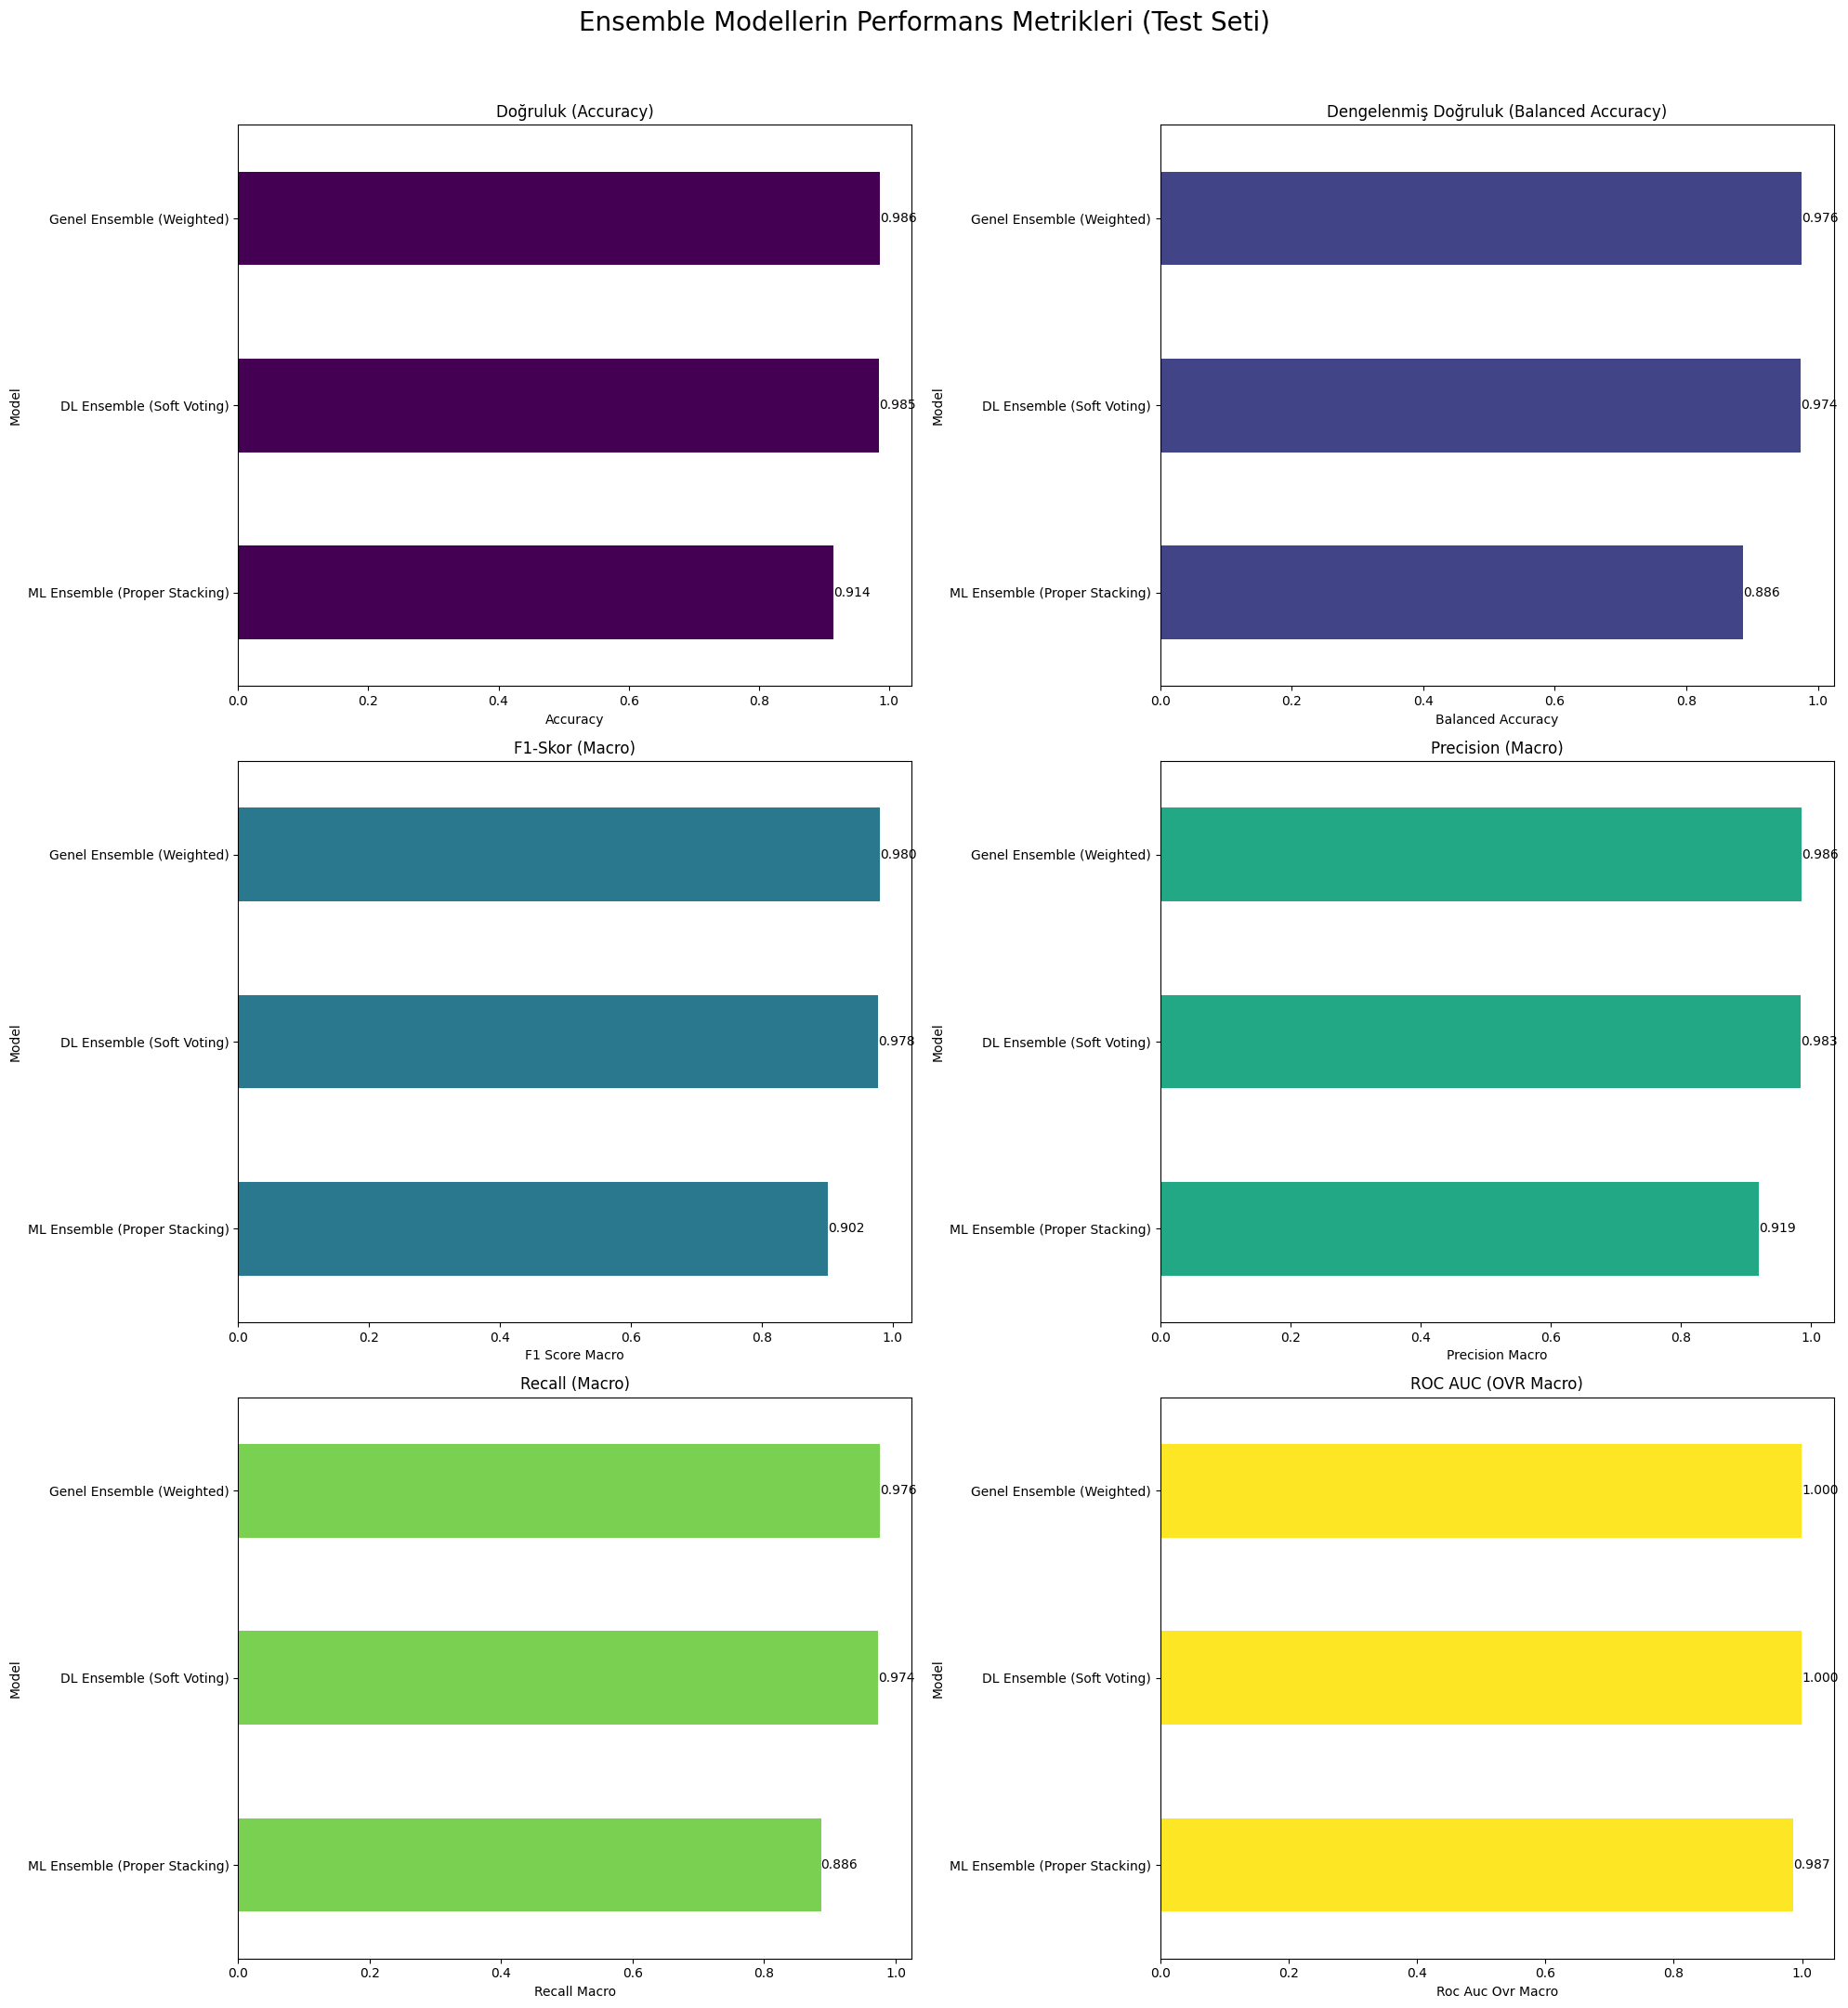

Grafik '/content/drive/MyDrive/Colab_ECG_Data/models/ensemble/ensemble_performance_chart.png' adresine kaydedildi.


In [11]:
# --- HÜCRE 7: Sonuçların Tablosu ve Görselleştirilmesi ---

# Tabloyu oluştur
results_df_ensemble = pd.DataFrame(ensemble_results)
results_df_ensemble.set_index('model', inplace=True)

print("\n\n--- ENSEMBLE MODELLERİN SONUÇ TABLOSU (TEST SETİ) ---")
print(results_df_ensemble.round(4))

# Sonuçları Drive'a kaydet
results_df_ensemble.to_csv(os.path.join(ENSEMBLE_PATH, 'ensemble_results_proper_stacking.csv'))
print(f"\nSonuçlar '{ENSEMBLE_PATH}' adresine 'ensemble_results_proper_stacking.csv' olarak kaydedildi.")

# Görselleştirme
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
fig.suptitle('Ensemble Modellerin Performans Metrikleri (Test Seti)', fontsize=20)
axes = axes.flatten()

metrics_to_plot = {
    'accuracy': 'Doğruluk (Accuracy)',
    'balanced_accuracy': 'Dengelenmiş Doğruluk (Balanced Accuracy)',
    'f1_score_macro': 'F1-Skor (Macro)',
    'precision_macro': 'Precision (Macro)',
    'recall_macro': 'Recall (Macro)',
    'roc_auc_ovr_macro': 'ROC AUC (OVR Macro)'
}
colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_to_plot)))

plot_counter = 0
for i, (metric, title) in enumerate(metrics_to_plot.items()):
    if metric in results_df_ensemble.columns and results_df_ensemble[metric].notna().any():
        ax = axes[plot_counter]
        plot_data = results_df_ensemble[metric].dropna().astype(float)
        plot_data.sort_values().plot(
            kind='barh', ax=ax, color=colors[i], title=title
        )
        ax.set_xlabel(metric.replace('_', ' ').title())
        ax.set_ylabel("Model")
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f')
        plot_counter += 1

if plot_counter < len(axes):
    for i in range(plot_counter, len(axes)):
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Grafik olarak da kaydet
fig_save_path = os.path.join(ENSEMBLE_PATH, 'ensemble_performance_chart.png')
fig.savefig(fig_save_path)
print(f"Grafik '{fig_save_path}' adresine kaydedildi.")

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

# --- HATA ALMAMAK İÇİN HER ŞEYİ BAŞTAN YÜKLÜYORUZ ---
print("1. Gerekli dosyalar ve model diskten yükleniyor...")

# 1. DOSYA YOLLARINI AYARLA (Senin sunucu yapına göre)
BASE_PATH = '/media/data/repo/bitirme-projesi'
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
ENSEMBLE_PATH = os.path.join(MODELS_PATH, 'ensemble')
ML_GAN_MODELS_PATH = os.path.join(MODELS_PATH, 'gan_balanced')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')
os.makedirs(RESULTS_PATH, exist_ok=True)

CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']

# 2. TEST VERİSİNİ YÜKLE
# Not: Modeli denerken ham veriyi (feat) alıp scale etmemiz lazım
X_test_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test_feat.npy'))
y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))

# 3. SCALER VE IMPUTER YÜKLE (Veriyi modele hazırlamak için)
scaler_path = os.path.join(MODELS_PATH, 'scaler.pkl')
if not os.path.exists(scaler_path):
     scaler_path = os.path.join(ML_GAN_MODELS_PATH, 'scaler_balanced.pkl')

print(f"   Scaler yükleniyor: {scaler_path}")
scaler = joblib.load(scaler_path)
imputer = SimpleImputer(strategy='mean')

# Veriyi dönüştür (Transform)
X_test_imputed = imputer.fit_transform(X_test_feat)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. MODELİ YÜKLE (NameError almamak için diski okuyoruz)
model_path = os.path.join(ENSEMBLE_PATH, 'ml_stacking_proper_model.pkl')
print(f"   Model yükleniyor: {model_path}")

try:
    stacking_model = joblib.load(model_path)
except FileNotFoundError:
    print("❌ HATA: Model dosyası bulunamadı! Lütfen önce modelin kaydedildiğinden emin ol.")
    raise

# --- RAPORLAMA KISMI ---
print("\n2. Sınıf Bazlı Performans Metrikleri Hesaplanıyor...")

# Tahminleri Al
y_pred_probs = stacking_model.predict_proba(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Raporu Oluştur (Dictionary formatında)
report_dict = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

# DataFrame'e çevir
df_report = pd.DataFrame(report_dict).transpose()

# Sütun isimlerini ve yuvarlamayı ayarla
df_report.columns = ['Precision (Kesinlik)', 'Recall (Duyarlılık)', 'F1-Score', 'Support (Sayı)']
df_report = df_report.round(4)

# Ekrana Bas (Jüriye göstereceğin tablo bu)
print("\n✅ TABLO 4.X: Stacking Ensemble Model Performansı")
print("-" * 70)
print(df_report)
print("-" * 70)

# CSV ve Excel olarak kaydet
df_report.to_csv(os.path.join(RESULTS_PATH, 'sinif_bazli_performans_ml.csv'))
print(f"📄 CSV dosyası kaydedildi: {os.path.join(RESULTS_PATH, 'sinif_bazli_performans_ml.csv')}")

# Görselleştirme (Teze yapıştırmalık resim)
plt.figure(figsize=(10, 6))
# 'accuracy' satırını görselden çıkaralım (Tablo daha temiz dursun)
df_plot = df_report.drop(['accuracy'], errors='ignore') 

sns.heatmap(df_plot.iloc[:, :-1], annot=True, cmap='Blues', fmt='.4f', linewidths=1, cbar=False)
plt.title('Sınıf Bazlı Performans Metrikleri (Stacking ML)', fontsize=14)
plt.yticks(rotation=0) 
plt.tight_layout()

img_path = os.path.join(RESULTS_PATH, 'performans_tablosu_gorsel_ml.png')
plt.savefig(img_path, bbox_inches='tight', dpi=300)
print(f"🖼️ Tablo görseli kaydedildi: {img_path}")
plt.show()